In [1]:
import sys
from pathlib import Path

# Add parent directory to Python path
parent_dir = Path.cwd().parent
sys.path.insert(0, str(parent_dir))

import pychnosz
from aqorg import Estimate#, Joback
import propfit
import pandas as pd

In [2]:
#pf = propfit.PropFit(filename='default_database_with_aq_props.csv', props=['Gh','Hh','Cph','V','Hig','Sig','Cpig','Gaq','Haq','Cpaq'])

In [3]:
#pf.dataprep()

In [4]:
#df = pd.read_csv('properties and groups.csv')
#df.head()

In [5]:
## where aqueous properties would be specified?
#pf.group_property_estimator('properties and groups.csv', props = ['Gh','Hh','Cph','V','Hig','Sig','Cpig','Gaq','Haq','Cpaq'])

In [6]:
#pf.generate()

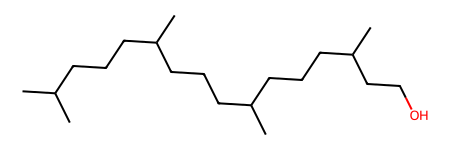

In [7]:
aq_props = Estimate(name="phytanol", state="aq", aq_method="aqueous", aq_group_data="aq props.csv")

In [8]:
aq_props.Gaq, aq_props.Haq, aq_props.Saq, aq_props.Cpaq, aq_props.V

(-15.3874, -747.0332, 507.704, 1736.2439, 334.0076)

---

### loading hyd props and gas props CSVs and summing groups

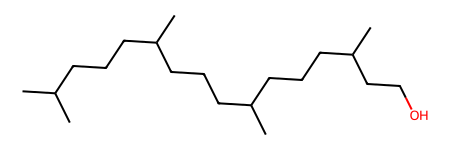

In [9]:
aq_props = Estimate(name="phytanol", state="aq",
                    aq_method="default hyd + ig", ig_method="custom",
                    hyd_group_data="hyd props.csv",
                    ig_group_data="gas props.csv", round_sf=True)

In [10]:
aq_props.Gaq, aq_props.Haq, aq_props.Saq, aq_props.Cpaq, aq_props.V

(-29.5909,
 -746.2512999999999,
 np.float64(557.9652403152813),
 1758.6686,
 334.0076)

---

### calculating gas properties first, then inputting them into Estimate()

In [ ]:
gas_props = Estimate(name="phytanol", state="gas", ig_method="custom", ig_group_data="gas props.csv", round_sf=False)

In [ ]:
aq_props = Estimate(name="phytanol", state="aq", hyd_group_data="hyd props.csv", aq_method="default hyd + ig",
                    Gig = gas_props.Gig,
                    Hig = gas_props.Hig,
                    Sig = gas_props.Sig, 
                    Cpig = gas_props.Cpig,
                    round_sf=False,
                   )

In [ ]:
aq_props.Gaq, aq_props.Haq, aq_props.Saq, aq_props.Cpaq, aq_props.V